# SDA: Kernel density estimation (KDE)

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [8]:
plt.rcParams["figure.figsize"] = (6, 3)
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

**Step 1**: Use the `gaussian_kde` function from `scipy.stats` to find a Gaussian KDE representation of the data in the histogram below

Optimal bandwidth: 0.422


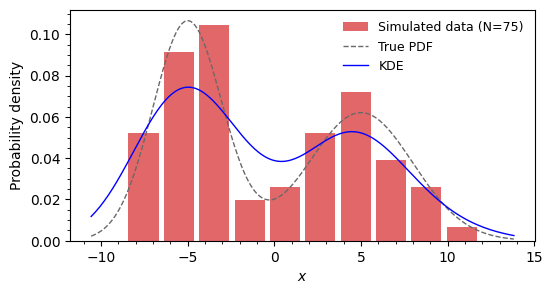

In [9]:
# Simulate from two Gaussian distributions 
mu1, mu2 = -5, 5
sig1, sig2 = 2, 3
n1, n2 = 40, 35
x1 = stats.norm.rvs(mu1, sig1, size=n1)
x2 = stats.norm.rvs(mu2, sig2, size=n2)
x = np.hstack([x1, x2])

# Plot the data
plt.hist(x, density=True, label=f'Simulated data (N={x.size})', rwidth=0.85, color='tab:red', alpha=0.7)
plt.xlabel(r'$x$')
plt.ylabel('Probability density')

# Plot the true PDFs
x_grid = np.linspace(np.min(x)-2, np.max(x)+2, 200)
g1 = stats.norm.pdf(x_grid, mu1, sig1)
g2 = stats.norm.pdf(x_grid, mu2, sig2)
norm1 = n1/(n1+n2)
norm2 = n2/(n1+n2)
plt.plot(x_grid, norm1*g1 + norm2*g2, '--', lw=1.0, color='dimgray', label='True PDF')

# Calculate and plot the KDE
KDE = stats.gaussian_kde(x)
bandwidth_value = KDE.factor 
print(f"Optimal bandwidth: {bandwidth_value:.3f}")
plt.plot(x_grid, KDE(x_grid), '-', lw=1.0, color='blue', label='KDE')

# Add the legend in the end
plt.legend(loc='upper right', frameon=False, fontsize=9)
plt.show()

**Step 2**: Show the result when you change the bandwidth from its default value to 0.1 and 1 (see [documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gaussian_kde.html)).

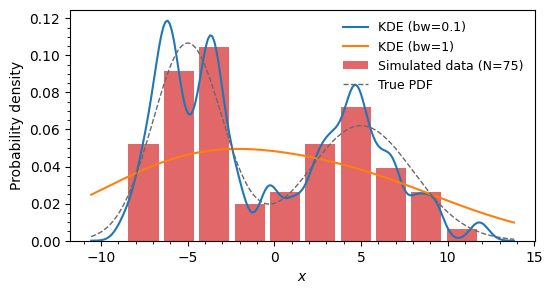

In [12]:
for bandwidth in [0.1, 1]:
    KDE = stats.gaussian_kde(x, bw_method=bandwidth)
    plt.plot(x_grid, KDE(x_grid), label=f'KDE (bw={bandwidth})')

plt.hist(x, density=True, label=f'Simulated data (N={x.size})', rwidth=0.85, color='tab:red', alpha=0.7)
plt.xlabel(r'$x$')
plt.ylabel('Probability density')
plt.plot(x_grid, norm1*g1 + norm2*g2, '--', lw=1.0, color='dimgray', label='True PDF')
plt.legend(loc='upper right', frameon=False, fontsize=9)
plt.show()